#### Case opti-4: Isobaric evaporation of ammonia in a large tank for long-term storage


In [10]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

#import optimization class
from cryoevap.optimize import Opti

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

#### Setup tank and cryogen properties

Overall heat transfer coefficient calculation from the wall exam

In [25]:
h_L = 124.96 # W/m2/K-1
h_env = 396 # W/m2/L-1

In [38]:
d_eq

np.float64(61.20143922212922)

In [62]:
# Wall heat transfer coefficient
k_w = 0.0411

# Equivalent diameter
d_eq = (d_o-d_i)/np.log(d_o/d_i)

# Overall heat transfer coefficient
U = (d_o/d_i * 1/h_L +  1/h_env + d_o/d_eq * (e/2)/k_w)**(-1)
#U = (1/h_L +  1/h_env + (e/2)/k_w)**(-1)
print("U = %.5f W m^-2 K^-1 " % U)

U = 0.08914 W m^-2 K^-1 


In [ ]:
np

In [11]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 5.3286+273.15 # Temperature of the environment K

#V_tank = 60000 # Tank volume / m^3
V_tank = 88023.6952 # Tank volume / m^3

# a = 0.7077
a    = 0.5
d_i  = ((4 * V_tank)/(np.pi * a))**(1/3) # internal diameter / m
e    = 10.6972*2 - 10.24*2
# d_i    = 66     # Internal diameter / m
d_o  = d_i + e   # External diameter / m
# Thickness of the in % of the internal diameter
# ST = 1.02
# d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.087 # 0.08 # W/m2/K
U_V = 0.087 # 0.08 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.95 

# Specify tank operating pressure
P = 101325 # Pa

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)
large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = None, Q_roof = 0, eta_w = 0.70)

# # Initialise cryogen
cryogen = Cryogen(name = "ammonia")
cryogen.set_coolprops(P)

# # Set cryogen
large_tank.cryogen = cryogen

# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

The initial evaporation rate of ammonia is 76.8 kg/h


Calculate initial evaporation rate and transient period

In [12]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of ammonia is 76.8 kg/h
Transient period = 367113.024 s 
Simulation time: 102 h
BOR = 0.003 %


#### Simulation setup and execution

In [13]:
# Define vertical spacing
dz = 0.05

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 720 hours
evap_time = 3600 * 24 * 7 * 3

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 3600

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

# Simulate the evaporation
large_tank.evaporate(evap_time)

In [14]:
# Save large_tank.data using pkl
import pickle
with open('large_tank_data_LF95_3weeks_wo_wall.pkl', 'wb') as f:
    pickle.dump(large_tank.data, f)

#### Visualisation of results

#### Vapour temperature

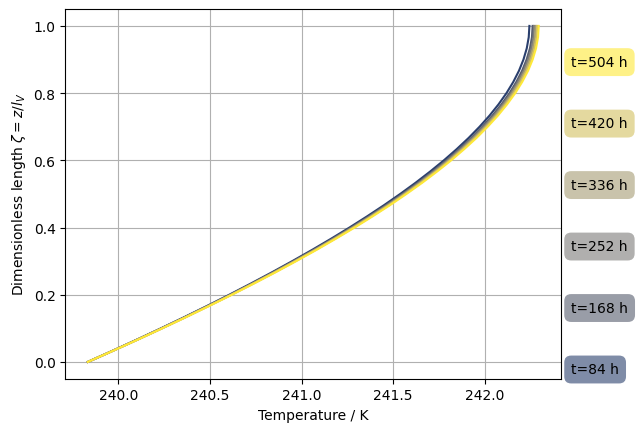

In [15]:
# Visualise the plot
large_tank.plot_tv(t_unit='h')

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

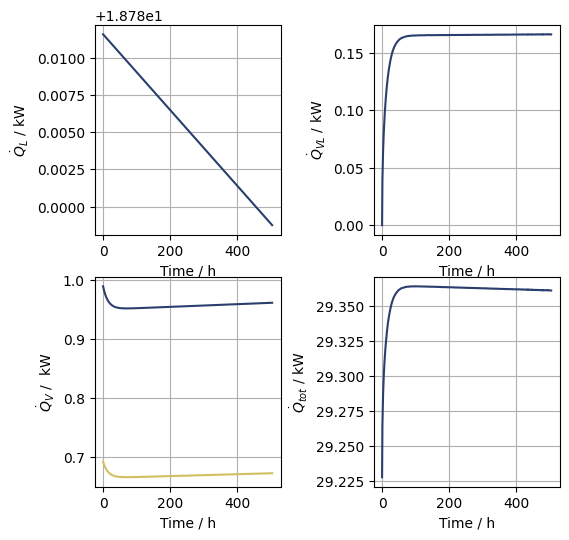

In [16]:
large_tank.plot_Q(unit='kW', t_unit='h')

#### Plot liquid volume

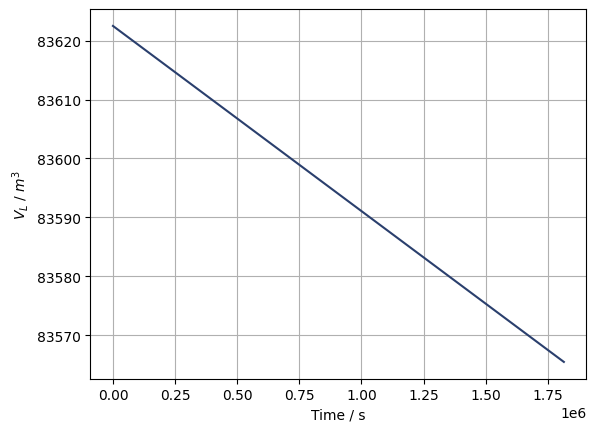

In [17]:
large_tank.plot_V_L()

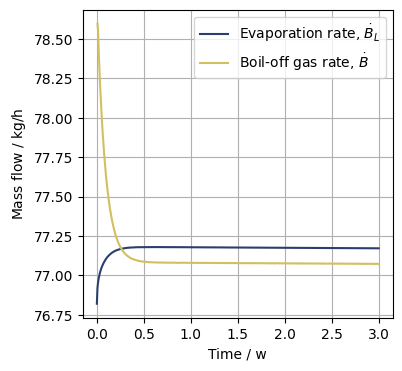

In [18]:
large_tank.plot_BOG(unit='kg/h', t_unit='w')

Optional: CSV data export

If evaporation data is intended to be post-processed in another software, it can be exported readily with the help of the Pandas package.

In [19]:
# Import pandas 
import pandas as pd

In [20]:
# Create dataframe from dictionary
df_evap = pd.DataFrame.from_dict(large_tank.data)

# Save file to the current working directory
df_evap.to_csv('methane_165000m3.csv')

# Show the first five columns of the dataframe in console
df_evap.head()

,Time,Tv_avg,rho_V_avg,Q_VL,Q_L,Q_V,V_L,B_L,BOG,drho_V_avg,dV_L,T_BOG,Q_Vw,Q_tot
0,0,239.834319,0.889927,-1.711862e-11,18791.574155,989.030219,83622.510440,0.021339,0.021339,0.000000e+00,0.000000,239.834319,692.321153,29227.526640
1,3600,239.941075,0.889522,3.873319e+01,18791.548807,986.323261,83622.397643,0.021366,0.021832,-1.123069e-07,-0.000031,239.953182,690.426283,29264.339613
2,7200,240.036987,0.889118,5.367251e+01,18791.523443,983.893724,83622.284772,0.021376,0.021822,-1.077637e-07,-0.000031,240.071763,688.725607,29277.552891
3,10800,240.125252,0.888746,6.434398e+01,18791.498070,981.659830,83622.171860,0.021382,0.021792,-9.941634e-08,-0.000031,240.189816,687.161881,29286.635265
4,14400,240.207109,0.888402,7.293175e+01,18791.472689,979.589814,83622.058917,0.021387,0.021766,-9.224301e-08,-0.000031,240.306471,685.712870,29293.748643


In [21]:
# BOR = (1 - large_tank.data['V_L'][-1]/large_tank.data['V_L'][0])* (86400/large_tank.data['Time'][-1])
BOR = large_tank.BOR()
print("BOR = %.3e %%" % (100 * BOR))

BOR = 3.249e-03 %


In [22]:
large_tank.BOR()

np.float64(3.2492887579142826e-05)

In [23]:
large_tank.data['Time'][-1]

np.int64(1814400)

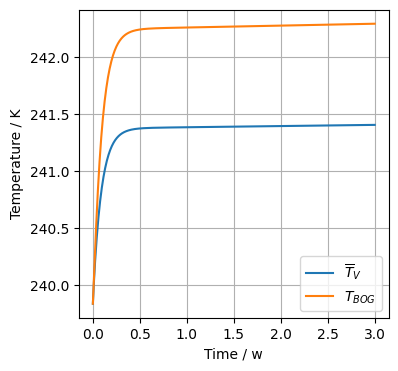

In [24]:
large_tank.plot_tv_BOG(t_unit='w')

#### References



F. Huerta, V. Vesovic, A realistic vapour phase heat transfer model for the weathering of LNG stored in large tanks, Energy, 174 (2019) 280-291.